## VAR Model Implementation (Vector Autoregression (VAR) for Inter-Stock Influence) 

In [2]:
# Importing required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR

from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

In [3]:
# Data download

data = yf.download(['KO', 'PEP'], start='2005-01-01')
close_prices = data['Close'][['KO', 'PEP']].dropna()

close_prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2005-01-03,10.941303,28.442066
2005-01-04,10.788539,28.239458
2005-01-05,10.738491,28.272316
2005-01-06,10.828042,28.474916
2005-01-07,10.841217,28.721329


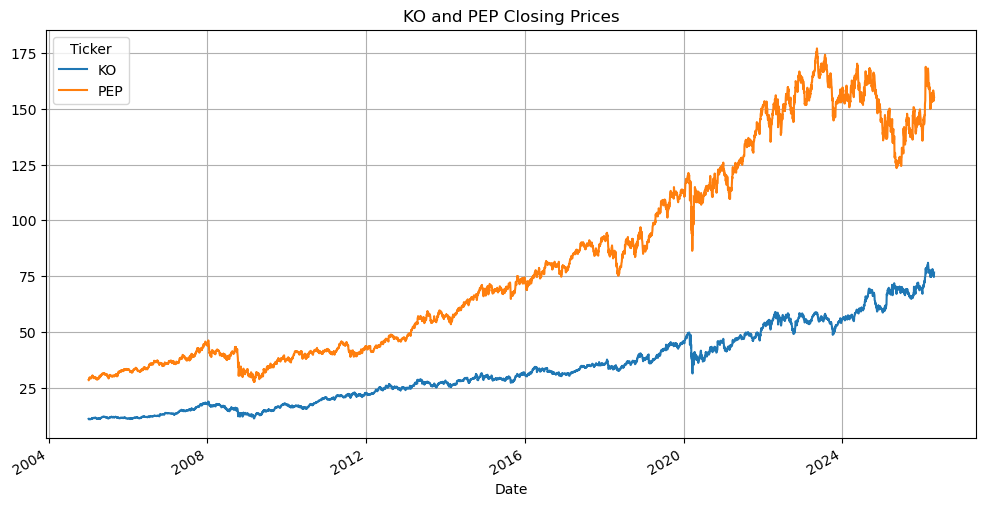

In [4]:
# Plotting data

close_prices.plot(figsize=(12,6), title='KO and PEP Closing Prices')
plt.grid()
plt.show()

In [5]:
# Introducing function for ADF test

def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    
    print(f"{name}")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    
    if result[1] < 0.05:
        print("Stationary\n")
    else:
        print("Non-stationary\n")

In [6]:
# Checking Stionarity

adf_test(close_prices['KO'], 'KO')
adf_test(close_prices['PEP'], 'PEP')

KO
ADF Statistic: 0.734097
p-value: 0.990494
Non-stationary

PEP
ADF Statistic: -0.114151
p-value: 0.948011
Non-stationary



In [7]:
# Differencing 

diff_data = close_prices.diff().dropna()

diff_data.head()

Ticker,KO,PEP
Date,,
2005-01-04,-0.152764,-0.202608
2005-01-05,-0.050048,0.032858
2005-01-06,0.089551,0.202600
2005-01-07,0.013175,0.246412
2005-01-10,0.060579,0.717356


In [8]:
# Check Stationarity Again

adf_test(diff_data['KO'], 'KO Differenced')
adf_test(diff_data['PEP'], 'PEP Differenced')


KO Differenced
ADF Statistic: -17.010268
p-value: 0.000000
Stationary

PEP Differenced
ADF Statistic: -15.227185
p-value: 0.000000
Stationary



In [9]:
# Train/Test Split

train = diff_data[:-10]
test = diff_data[-10:]

In [10]:
# Lag Selection

model = VAR(train)

lag_results = model.select_order(maxlags=15)
print(lag_results.summary())

C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -2.272      -2.269      0.1031      -2.271
1       -2.283     -2.276*      0.1020      -2.280
2       -2.284      -2.271      0.1019      -2.279
3       -2.283      -2.266      0.1020      -2.277
4       -2.287      -2.265      0.1016      -2.279
5       -2.288      -2.261      0.1015      -2.278
6       -2.290      -2.258      0.1013      -2.279
7       -2.294      -2.257      0.1009      -2.281
8       -2.293      -2.251      0.1009      -2.279
9       -2.296      -2.249      0.1007      -2.280
10      -2.299      -2.247      0.1004     -2.281*
11      -2.298      -2.241      0.1005      -2.278
12      -2.299      -2.237      0.1004      -2.277
13      -2.300      -2.233      0.1003      -2.276
14     -2.300*      -2.228     0.1003*      -2.275
15      -2.299      -2.223      0.1003      -2.273
-------------------------------

In [47]:
lag_order = lag_results.aic

In [12]:
# Fit VAR Model

var_model = model.fit(lag_order)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 25, Apr, 2026
Time:                     11:41:16
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -2.22866
Nobs:                     5336.00    HQIC:                  -2.27522
Log likelihood:          -8947.95    FPE:                   0.100238
AIC:                     -2.30021    Det(Omega_mle):       0.0991570
--------------------------------------------------------------------
Results for equation KO
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.013394         0.005575            2.402           0.016
L1.KO           0.023741         0.019107            1.242           0.214
L1.PEP         -0.024041         0.007130           -3.372           0.001
L2.KO       

In [13]:
# Forecasting

forecast_input = train.values[-lag_order:]

forecast = var_model.forecast(y=forecast_input, steps=10)

forecast_df = pd.DataFrame(forecast, index=test.index, columns=['KO', 'PEP'])

forecast_df

,KO,PEP
Date,,
2026-04-13,0.089249,0.047620
2026-04-14,-0.235991,-0.202672
2026-04-15,0.064624,0.133113
2026-04-16,0.091899,-0.095147
2026-04-17,-0.125173,-0.128911
2026-04-20,0.115215,0.170650
2026-04-21,-0.025566,0.062177
2026-04-22,0.047539,0.062655
2026-04-23,0.026348,-0.068238


In [14]:
# Convert back to price

# Convert forecast from differenced values back to actual price levels

# Last actual observed values before forecast period
last_values = close_prices.iloc[-11]

# Convert cumulative sum of differences back to price
forecast_prices = forecast_df.cumsum()
forecast_prices = forecast_prices + last_values

# Display reconstructed forecast prices
forecast_prices

,KO,PEP
Date,,
2026-04-13,77.559250,157.107617
2026-04-14,77.323259,156.904945
2026-04-15,77.387883,157.038058
2026-04-16,77.479782,156.942911
2026-04-17,77.354609,156.814000
2026-04-20,77.469824,156.984650
2026-04-21,77.444257,157.046828
2026-04-22,77.491797,157.109483
2026-04-23,77.518145,157.041245


In [15]:
print(forecast_prices.head())

                   KO         PEP
Date                             
2026-04-13  77.559250  157.107617
2026-04-14  77.323259  156.904945
2026-04-15  77.387883  157.038058
2026-04-16  77.479782  156.942911
2026-04-17  77.354609  156.814000


In [16]:
# Evaluation

actual = close_prices.iloc[-10:]

# KO
rmse_ko = np.sqrt(mean_squared_error(actual['KO'], forecast_prices['KO']))
mae_ko = mean_absolute_error(actual['KO'], forecast_prices['KO'])

# PEP
rmse_pep = np.sqrt(mean_squared_error(actual['PEP'], forecast_prices['PEP']))
mae_pep = mean_absolute_error(actual['PEP'], forecast_prices['PEP'])

print("KO RMSE:", rmse_ko)
print("PEP RMSE:", rmse_pep)

# MAPE calculation
mape_ko = np.mean(np.abs((actual['KO'] - forecast_prices['KO']) / actual['KO'])) * 100
mape_pep = np.mean(np.abs((actual['PEP'] - forecast_prices['PEP']) / actual['PEP'])) * 100

print("KO MAPE:", mape_ko)
print("PEP MAPE:", mape_pep)

KO RMSE: 1.9335544649396819
PEP RMSE: 1.7279488062332897
KO MAPE: 2.411867309006475
PEP MAPE: 0.9722280244777775


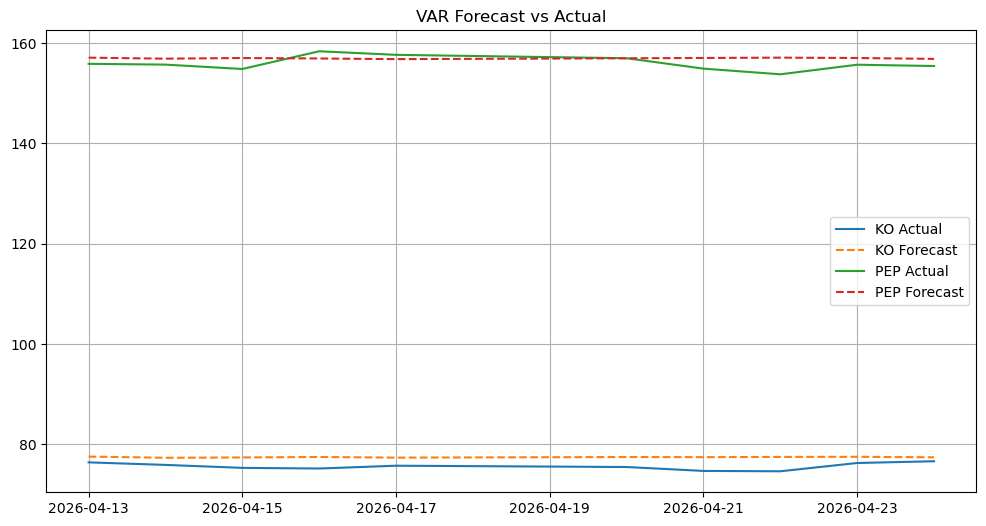

In [17]:
# Plotting results

plt.figure(figsize=(12,6))

plt.plot(actual.index, actual['KO'], label='KO Actual')
plt.plot(actual.index, forecast_prices['KO'], '--', label='KO Forecast')

plt.plot(actual.index, actual['PEP'], label='PEP Actual')
plt.plot(actual.index, forecast_prices['PEP'], '--', label='PEP Forecast')

plt.legend()
plt.title("VAR Forecast vs Actual")
plt.grid()
plt.show()

In [18]:
results_var = pd.DataFrame({
    'Stock': ['KO', 'PEP'],
    'RMSE': [rmse_ko, rmse_pep],
    'MAE': [mae_ko, mae_pep],
    'MAPE (%)': [mape_ko, mape_pep]
})

results_var

,Stock,RMSE,MAE,MAPE (%)
0,KO,1.933554,1.818180,2.411867
1,PEP,1.727949,1.510789,0.972228


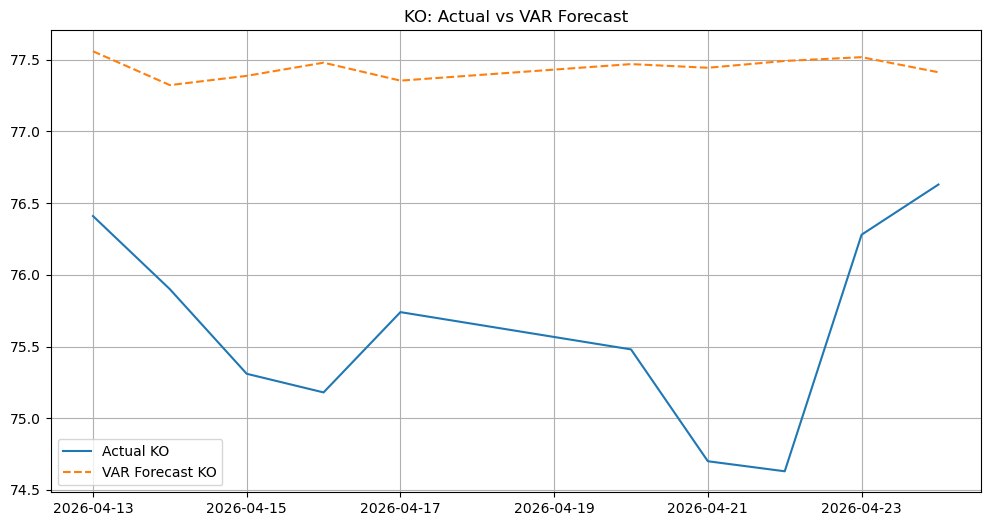

In [19]:
#KO Plot

plt.figure(figsize=(12,6))
plt.plot(actual.index, actual['KO'], label='Actual KO')
plt.plot(actual.index, forecast_prices['KO'], '--', label='VAR Forecast KO')

plt.title('KO: Actual vs VAR Forecast')
plt.legend()
plt.grid()
plt.show()

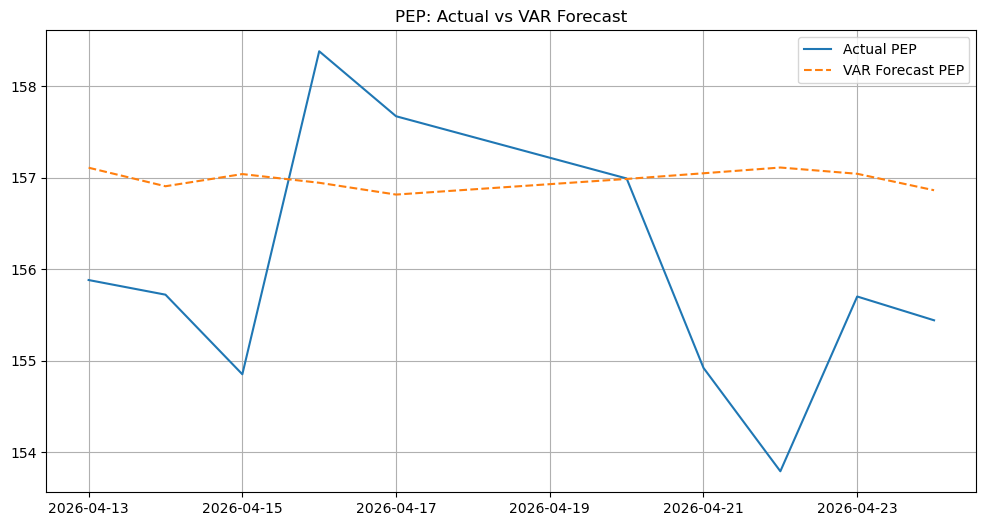

In [20]:
#PEP Plot

plt.figure(figsize=(12,6))
plt.plot(actual.index, actual['PEP'], label='Actual PEP')
plt.plot(actual.index, forecast_prices['PEP'], '--', label='VAR Forecast PEP')

plt.title('PEP: Actual vs VAR Forecast')
plt.legend()
plt.grid()
plt.show()

In [21]:
print("Correlation between KO and PEP:")
print(close_prices.corr())

Correlation between KO and PEP:
Ticker        KO       PEP
Ticker                    
KO      1.000000  0.961107
PEP     0.961107  1.000000


In [22]:
# Compute correlation between KO and PEP
correlation_matrix = close_prices.corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
Ticker        KO       PEP
Ticker                    
KO      1.000000  0.961107
PEP     0.961107  1.000000


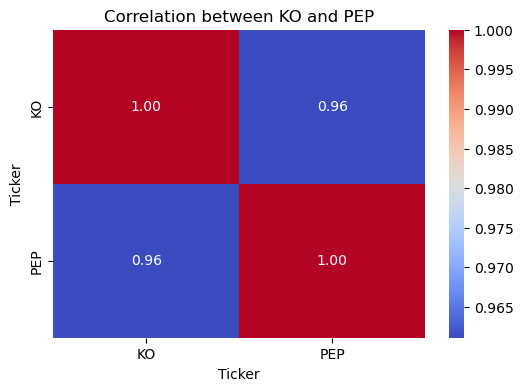

In [23]:
# Plotting correlation

plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation between KO and PEP")
plt.show()

END